In [ ]:
# ==========================================
# SPAM EMAIL DETECTION USING PIPELINE
# ==========================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# ==========================================
# Step 2: Load Dataset
# ==========================================
data = pd.read_csv("/content/drive/MyDrive/ML LAB EXPERIMENTS/spam_email.csv")   # change path if needed

print("First 5 rows:")
print(data.head())

First 5 rows:
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
# ==========================================
# Step 3: Text Cleaning Function
# ==========================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

data['Message'] = data['Message'].apply(clean_text)

In [ ]:
# ==========================================
# Step 4: Encode Labels
# ==========================================
le = LabelEncoder()
data['label'] = le.fit_transform(data['Category'])  # spam=1, ham=0

X = data['Message']
y = data['label']

In [ ]:
# ==========================================
# Step 5: Feature Extraction (TF-IDF)
# ==========================================
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(X)
y = y

In [ ]:
# ==========================================
# Step 6: Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ==========================================
# Step 7: Initialize Models
# ==========================================
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}


Training Naive Bayes
Accuracy: 0.9776

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



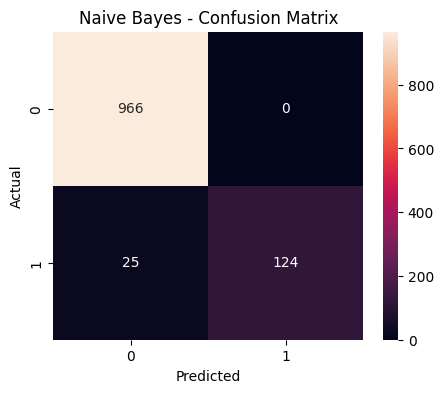


Training Logistic Regression
Accuracy: 0.9650

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.97      0.96      1115



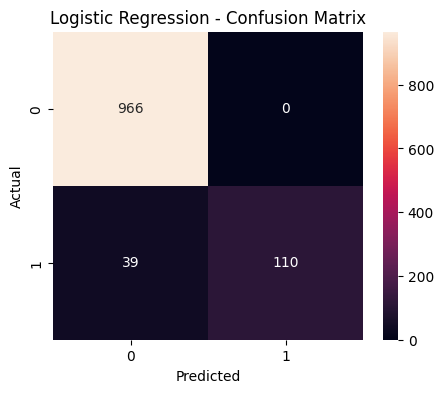


Training Support Vector Machine
Accuracy: 0.9785

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



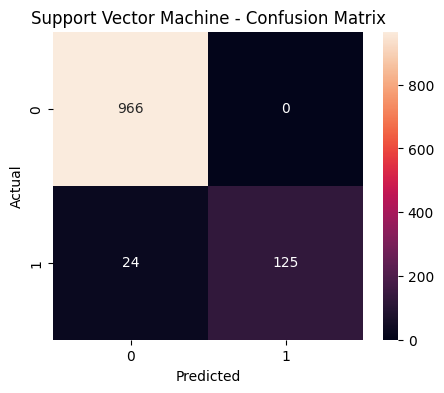


Training Decision Tree
Accuracy: 0.9632

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       966
           1       0.88      0.85      0.86       149

    accuracy                           0.96      1115
   macro avg       0.93      0.91      0.92      1115
weighted avg       0.96      0.96      0.96      1115



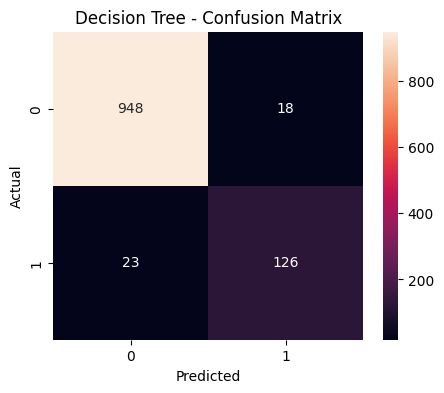


Training Random Forest
Accuracy: 0.9803

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



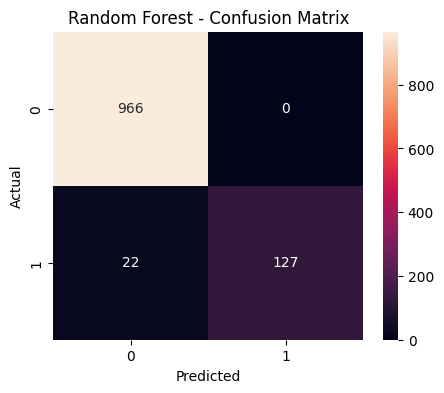

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ==========================================
# Step 8: Train and Evaluate Models
# ==========================================
for name, model in models.items():
    print("\n===================================")
    print(f"Training {name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

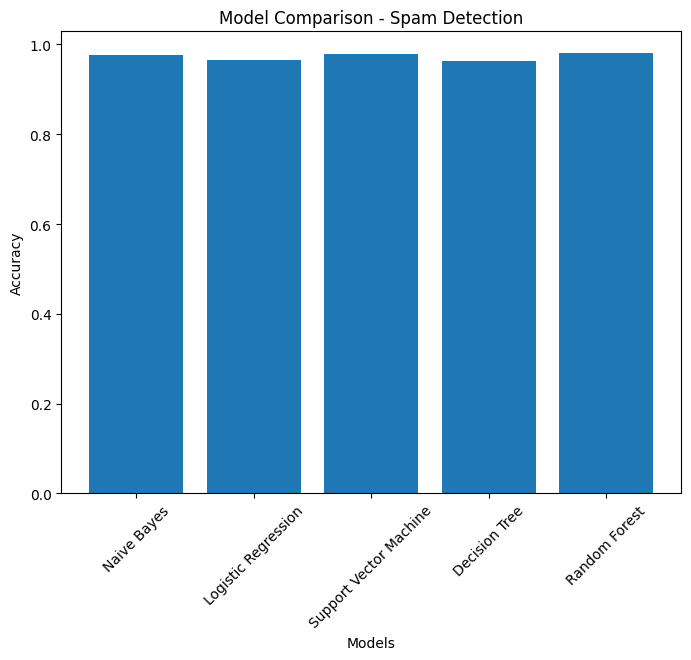

In [ ]:
# ==========================================
# Step 9: Comparison Graph
# ==========================================
plt.figure(figsize=(8,6))

model_names = list(results.keys())
accuracies = list(results.values())

plt.bar(model_names, accuracies)
plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Spam Detection")
plt.show()


In [ ]:
# ==========================================
# Step 10: Save Best Pipeline to Google Drive
# ==========================================

save_path = "/content/drive/MyDrive/ML LAB EXPERIMENTS/best_spam_pipeline.pkl"

best_model_name = max(results, key=results.get)

# Get the trained best model instance
best_model_instance = models[best_model_name]

# Create a pipeline with the fitted TF-IDF vectorizer and the best model
best_pipeline = Pipeline([
    ('tfidf', tfidf), # tfidf object is already fitted from Step 5
    ('classifier', best_model_instance)
])

print("\nBest Model:", best_model_name)

pickle.dump(best_pipeline, open(save_path, "wb"))

print("Pipeline Saved Successfully at:", save_path)


Best Model: Random Forest
Pipeline Saved Successfully at: /content/drive/MyDrive/ML LAB EXPERIMENTS/best_spam_pipeline.pkl
